# scDEF tutorial — whole adult planarian

21,612 cells from the flatworm *Schmidtea mediterranea* (Plass et al.), annotated at two resolutions (`clusters_coarse`, tissues; `clusters_neoblasts`, subtypes). A large, richly hierarchical data set: scDEF recovers a cell-type hierarchy and, on top of it, differentiation trajectories from the neoblast progenitors.

> **Running this notebook.** Fitting is the slow step — run top-to-bottom once; the fitted model is saved at the end, so you can re-open it with `scd.scDEF.load(...)` instead of re-fitting. The steps follow the reference [analysis workflow](../repo/docs/workflow.md).

## Known genes and ground-truth hierarchy (reference)

In [1]:
known_genes = {
    'dd_Smed_v6_659_0': 'piwi', 'dd_Smed_v6_332_0': 'prog-1', 'dd_Smed_v6_363_0': 'prog-2-2',
    'dd_Smed_v6_920_0': 'agat1', 'dd_Smed_v6_432_0': 'mhc', 'dd_Smed_v6_12634_0': 'myoD',
    'dd_Smed_v6_6208_0': 'chat', 'dd_Smed_v6_3977_0': 'snap25', 'dd_Smed_v6_1117_0': 'npp-18',
    'dd_Smed_v6_8548_0': 'ncam-2', 'dd_Smed_v6_19336_0': 'gbrb-1', 'dd_Smed_v6_9893_0': 'smed-coe',
    'dd_Smed_v6_8494_0': 'roboA', 'dd_Smed_v6_14852_0': 'netrin', 'dd_Smed_v6_13817_0': 'musashi',
    'dd_Smed_v6_1013_0': 'pmp-7', 'dd_Smed_v6_364_0': 'vim-1', 'dd_Smed_v6_11310_0': 'egfr',
}

In [2]:
true_hierarchy = {
    'stem cells': ['neoblast'],
    'neurons': ['ChAT neurons 1', 'ChAT neurons 2', 'GABA neurons', 'spp-11+ neurons',
                'npp-18+ neurons', 'cav-1+ neurons', 'neural progenitors'],
    'epidermis': ['early epidermal progenitors', 'activated early epidermal progenitors',
                  'epidermal neoblasts', 'epidermis', 'epidermis DVb', 'epidermis DVb neoblast',
                  'late epidermal progenitors 1', 'late epidermal progenitors 2'],
    'muscle': ['muscle body', 'muscle pharynx', 'muscle progenitors'],
    'parenchyma': ['pgrn+ parenchymal cells', 'ldlrr-1+ parenchymal cells',
                   'psap+ parenchymal cells', 'aqp+ parenchymal cells', 'parenchymal progenitors'],
    'secretory': ['secretory 1', 'secretory 2', 'secretory 3', 'secretory 4'],
    'pharynx': ['pharynx cell type progenitors', 'pharynx cell type'],
    'gut': ['gut progenitors', 'phagocytes', 'goblet cells'],
    'protonephridia': ['protonephridia'], 'pigment': ['pigment'],
    'otf+ cells 1': ['otf+ cells 1'], 'otf+ cells 2': ['otf+ cells 2'],
    'psd+ cells': ['psd+ cells'], 'glia': ['glia'],
}

## Load packages and data

In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import scdef as scd
import matplotlib.pyplot as plt

In [4]:
adata = sc.read_h5ad('../scdef_data/planaria/planaria_pp.h5ad')
# Already QC'd + HVG-filtered; raw counts are in the 'counts' layer, and the data ships a
# t-SNE + annotation colors. Rename transcript ids to gene symbols where known (so signatures
# and gene_score are readable).
adata.var['transcript_id'] = adata.var_names.astype(str)
adata.var_names = [known_genes.get(g, g) for g in adata.var_names]
adata.var_names_make_unique()
adata.obs['clusters_coarse'].value_counts()

clusters_coarse
stem cells        8075
epidermis         4391
neurons           2358
muscle            2351
parenchyma        2042
gut                745
secretory          466
pigment            321
pharynx            292
psd+ cells         174
otf+ cells 1       166
otf+ cells 2       127
protonephridia      80
glia                24
Name: count, dtype: int64

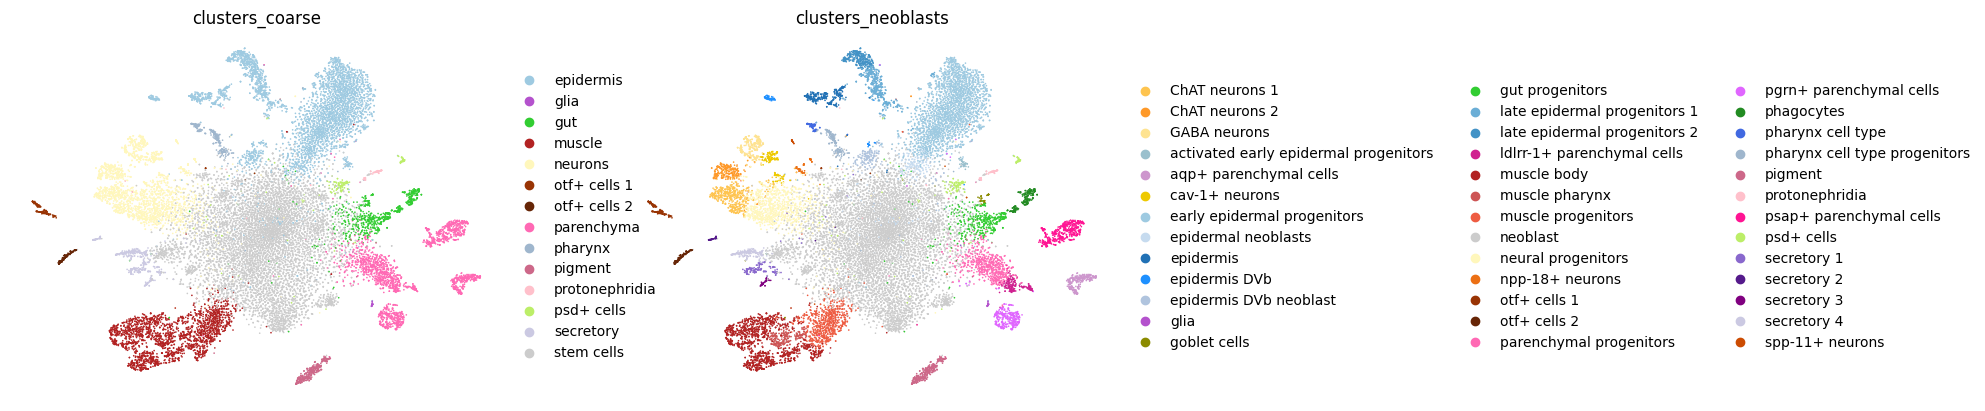

In [5]:
sc.pl.tsne(adata, color=['clusters_coarse', 'clusters_neoblasts'], frameon=False)

## Fit scDEF

A larger data set, so the fit takes longer; the defaults are fine.

In [6]:
model = scd.scDEF(adata, counts_layer='counts')
print(model)
model.fit(hierarchical_init=True)

scDEF object with 6 layers
	Layer names: L0, L1, L2, L3, L4, L5
	Layer sizes: 100, 40, 16, 6, 3, 1
	alpha parameter: 0.58
	Using BRD
	Number of batches: 1
Contains AnnData object with n_obs × n_vars = 21612 × 4900
    obs: 'n_genes', 'n_counts', 'clusters', 'clusters_neoblasts', 'clusters_coarse'
    var: 'n_cells', 'mean', 'std', 'transcript_id'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'clusters_neoblasts_colors', 'clusters_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'tsne'
    obsm: 'X_pca', 'X_tsne'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'


INFO:scDEF:Built hierarchical z/W init from KMeans (100 L0 clusters) using 'X_pca'.
INFO:scDEF:Each epoch contains 85 batches of size 256
 55%|█████▌    | 552/1000 [25:46<20:54,  2.80s/it, Loss=7.47e+6, Rel. impr.=-0.000586]
INFO:scDEF:Converged at epoch 553.
/home/pedro/projects/scDEF/repo/src/scdef/models/_scdef.py:3890: RuntimeWarning: overflow encountered in multiply
  return (np.exp(sigma2) - 1.0) * np.exp(2.0 * mu + sigma2)
INFO:scDEF:Updated adata.var: `gene_scale`
INFO:scDEF:Updated adata.obs with layer 0: `L0` and `L0_score` for all factors in layer 0
INFO:scDEF:Updated adata.obsm with layer 0: `X_L0`
INFO:scDEF:Updated adata.uns with layer 0 signatures: `L0_signatures`.
INFO:scDEF:Updated adata.obs with layer 1: `L1` and `L1_score` for all factors in layer 1
INFO:scDEF:Updated adata.obsm with layer 1: `X_L1`
INFO:scDEF:Updated adata.uns with layer 1 signatures: `L1_signatures`.
INFO:scDEF:Updated adata.obs with layer 2: `L2` and `L2_score` for all factors in layer 2
INFO:scDE

## Check, diagnose, filter, re-fit

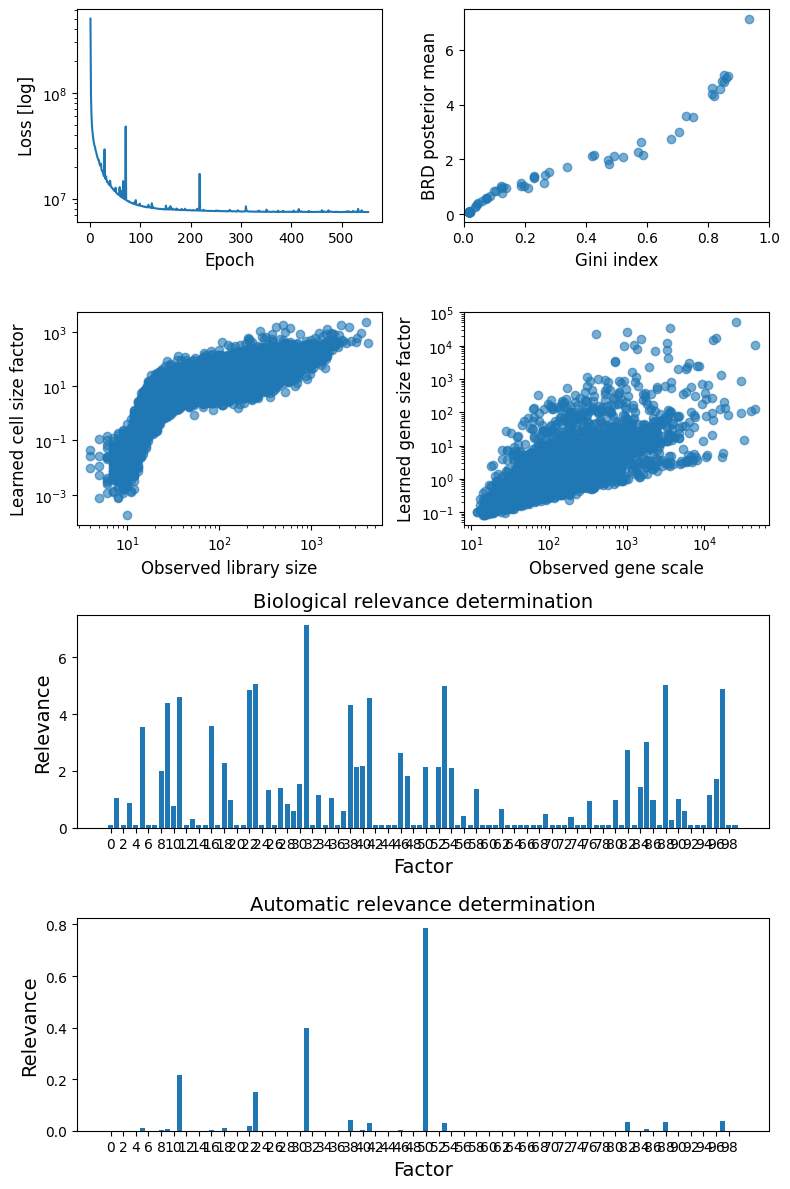

In [7]:
scd.pl.qc(model)

INFO:scDEF:factor_diagnostics: recomputing cached diagnostics (missing cached upper-layer factor lists; fit revision changed (-1 -> 1)).


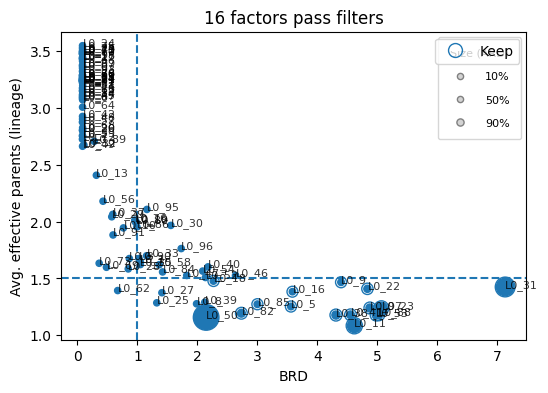

In [8]:
scd.tl.factor_diagnostics(model)
scd.pl.factor_diagnostics(model, annotate_factors=True)  # inspect before cutting

INFO:scDEF:filter_factors: cleared name-keyed caches (L0_signatures, L1_signatures, L2_signatures, L3_signatures, L4_signatures, L5_signatures, _factor_obs_fit_revision, _factor_obs_upper_lists_fixed, confident_signatures, factor_signatures). Re-run scdef.tools.set_confident_signatures to rebuild signatures, or scdef.tools.factor_diagnostics for the full diagnostics.
INFO:scDEF:Updated adata.var: `gene_scale`
INFO:scDEF:Updated adata.obs with layer 0: `L0` and `L0_score` for all factors in layer 0
INFO:scDEF:Updated adata.obsm with layer 0: `X_L0`
INFO:scDEF:Updated adata.uns with layer 0 signatures: `L0_signatures`.
INFO:scDEF:Updated adata.obs with layer 1: `L1` and `L1_score` for all factors in layer 1
INFO:scDEF:Updated adata.obsm with layer 1: `X_L1`
INFO:scDEF:Updated adata.uns with layer 1 signatures: `L1_signatures`.
INFO:scDEF:Updated adata.obs with layer 2: `L2` and `L2_score` for all factors in layer 2
INFO:scDEF:Updated adata.obsm with layer 2: `X_L2`
INFO:scDEF:Updated ada

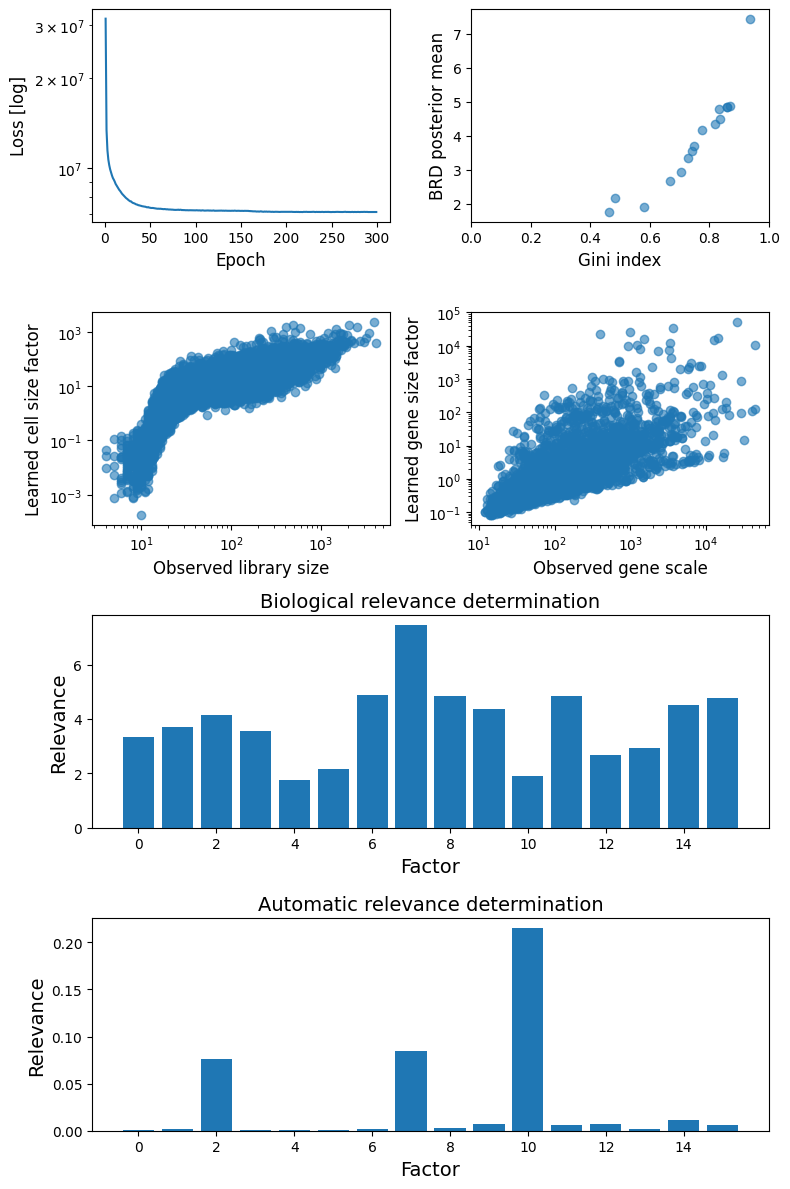

[16, 9, 4, 1, 1]


In [9]:
scd.tl.filter(model)
model.fit(hierarchical_init=True)
scd.pl.qc(model)
print([len(fl) for fl in model.factor_lists])

In [10]:
scd.tl.factor_diagnostics(model)  # refreshes diagnostics + gene signatures after the re-fit

INFO:scDEF:factor_diagnostics: recomputing cached diagnostics (missing cached upper-layer factor lists; fit revision changed (-1 -> 2)).


## Hierarchy of cell states

Leaves are specific cell types; nodes near the root aggregate a tissue. `show_signatures` prints the top genes driving each lineage — compare the recovered tree against the known `true_hierarchy` defined at the top.

INFO:scDEF:Updated scDEF graph


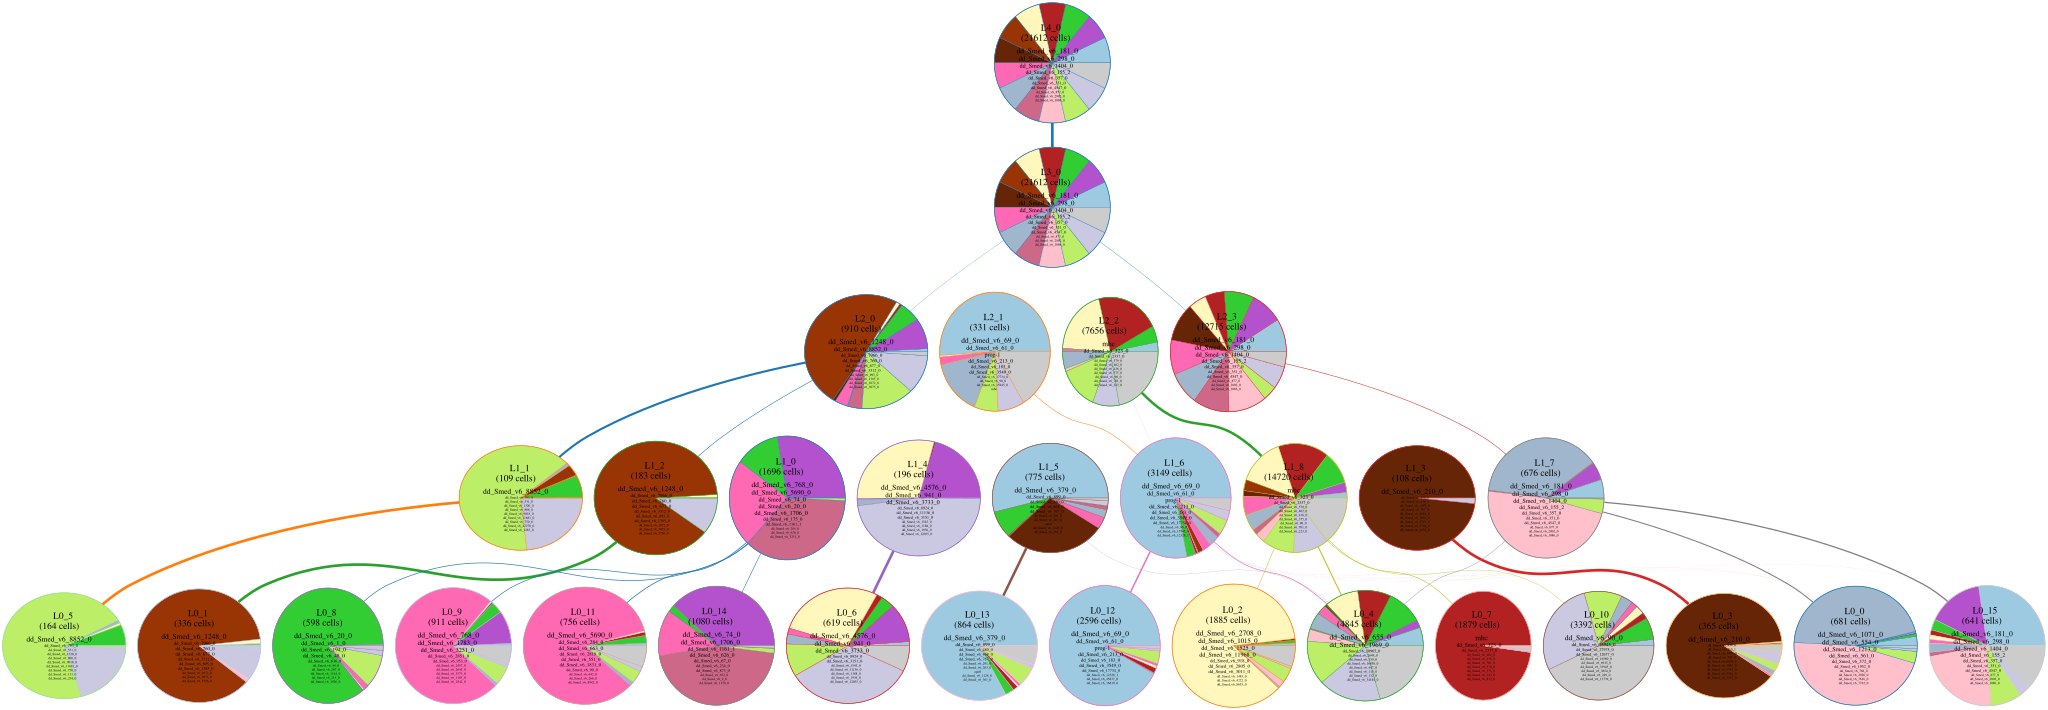

In [11]:
scd.pl.make_graph(model, wedged='clusters_coarse', show_signatures=True, n_cells_label=True)

Colour the tree by a single marker instead: a known driver localizing to one branch confirms the hierarchy captured that lineage's *program*, not just its cell counts. `mhc` (muscle) and `chat` (neurons) should light up their lineages, as in the paper.

INFO:scDEF:Updated scDEF graph


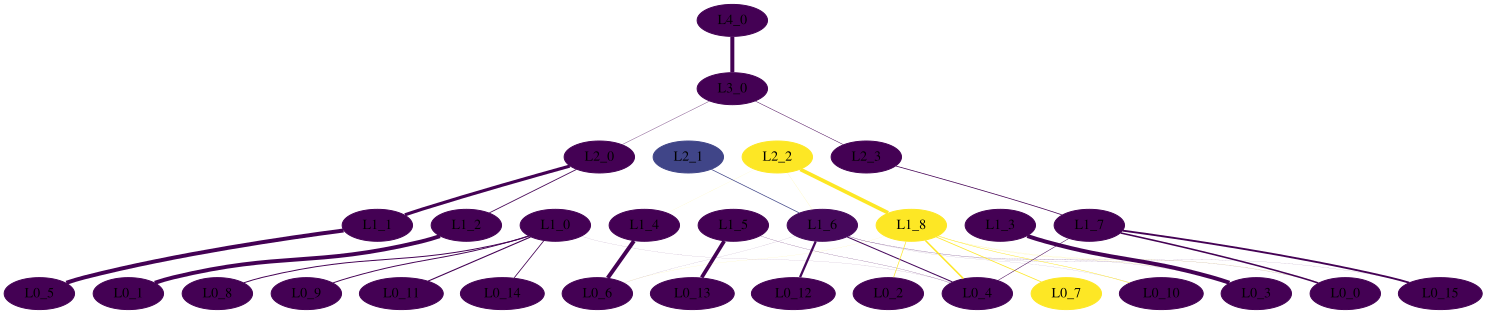

In [12]:
scd.pl.make_graph(model, gene_score='mhc', show_signatures=False)

INFO:scDEF:Updated scDEF graph


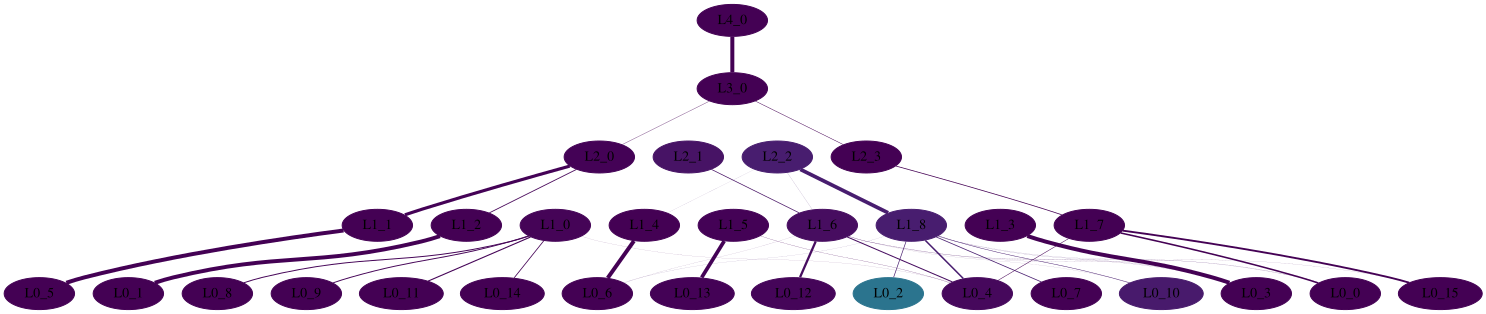

In [13]:
scd.pl.make_graph(model, gene_score='chat', show_signatures=False)

## Multi-layer UMAP by cell type

Layer 0 separates the differentiated cell types with neoblasts at the centre; upper layers progressively merge cell types within a tissue.

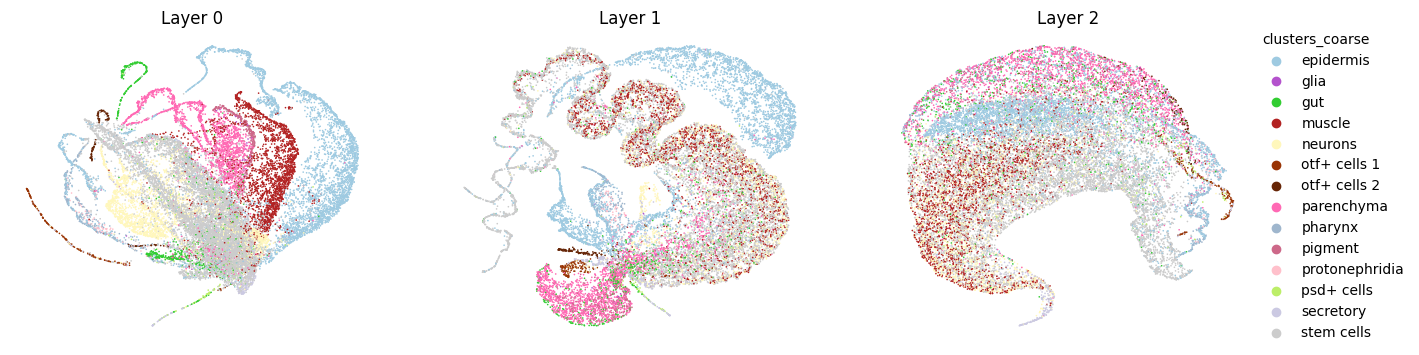

In [14]:
scd.tl.umap(model)
scd.pl.umap(model, color='clusters_coarse')

## Association of factors with cell types across layers

Many layer-0 factors map to neuronal subtypes, fewer in layer 1, and one at the top — the hierarchy captures cell types finely and aggregates them by tissue.

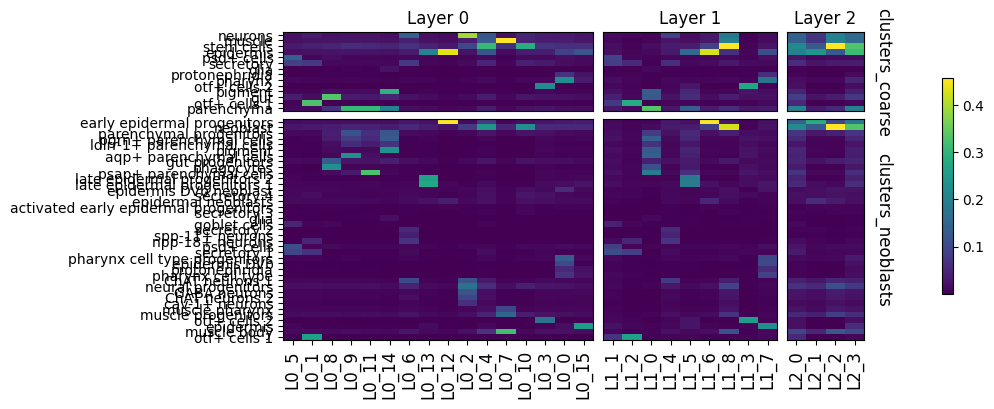

In [15]:
scd.pl.obs_scores(model, ['clusters_coarse', 'clusters_neoblasts'], mode='weights')

## Differentiation trajectories

A multi-level PAGA over the layers, then top-to-leaf differentiation paths (root neoblasts → differentiated leaves) scored per cell. `path_embedding` colours cells by position along a path with opacity by path affinity; `path_id='auto'` (default) shows the strongest-supported lineage.

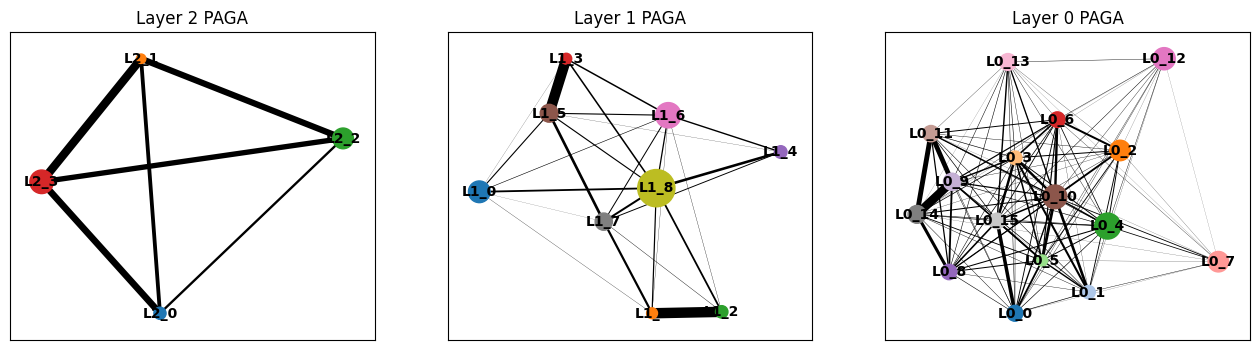

In [16]:
scd.tl.multilevel_paga(model, neighbors_rep='X_L0')
scd.pl.multilevel_paga(model)

In [17]:
scd.tl.build_differentiation_paths(model)
scd.tl.score_paths(model, paths_key='differentiation_paths')
model.adata.uns['differentiation_paths']   # inspect the paths; pass path_id=<i> to pick one

{'paths': [{'path_id': 0,
   'nodes': ['L4_0', 'L3_0', 'L2_1', 'L1_7', 'L0_0'],
   'type': 'differentiation',
   'path_weight_product': 3.709649225131478e-10},
  {'path_id': 1,
   'nodes': ['L4_0', 'L3_0', 'L2_2', 'L1_7', 'L0_0'],
   'type': 'differentiation',
   'path_weight_product': 1.4726117409749405e-09},
  {'path_id': 2,
   'nodes': ['L4_0', 'L3_0', 'L2_3', 'L1_7', 'L0_0'],
   'type': 'differentiation',
   'path_weight_product': 0.01551613995811938},
  {'path_id': 3,
   'nodes': ['L4_0', 'L3_0', 'L2_0', 'L1_2', 'L0_1'],
   'type': 'differentiation',
   'path_weight_product': 0.0061461389824497056},
  {'path_id': 4,
   'nodes': ['L4_0', 'L3_0', 'L2_1', 'L1_2', 'L0_1'],
   'type': 'differentiation',
   'path_weight_product': 1.4372179184458103e-10},
  {'path_id': 5,
   'nodes': ['L4_0', 'L3_0', 'L2_2', 'L1_2', 'L0_1'],
   'type': 'differentiation',
   'path_weight_product': 1.011560509225186e-09},
  {'path_id': 6,
   'nodes': ['L4_0', 'L3_0', 'L2_2', 'L1_8', 'L0_2'],
   'type': 'di

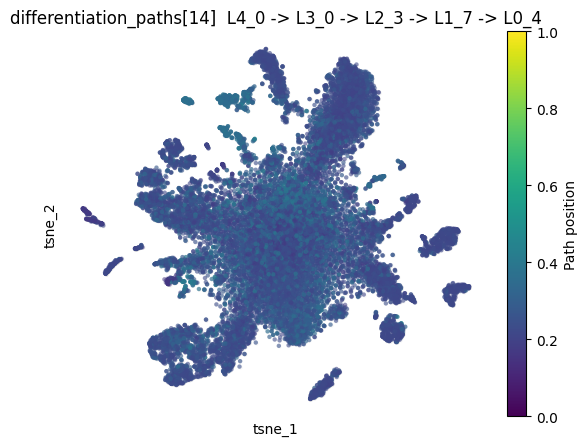

In [18]:
scd.pl.path_embedding(model, paths_key='differentiation_paths', basis='tsne', min_affinity=0.2)

## Save the fitted model

In [19]:
model.save('scdef-planaria', overwrite=True)